In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('./laptop_data2.csv')
df.head()

,brand,price,ram_gb,storage_gb,storage_type,screen_size,os,processor_brand,processor_series,generation
0,ASUS,37990,8,512.0,SSD,35.56,Windows 11,intel,i3,13
1,ASUS,39990,16,512.0,SSD,39.62,Windows 11,intel,i3,13
2,HP,69990,16,512.0,SSD,39.62,Windows 11,intel,i7,13
3,ASUS,56990,16,512.0,SSD,39.62,Windows 11,intel,i5,0
4,Acer,38990,16,512.0,SSD,39.62,Windows 11,amd,ryzen 5,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             945 non-null    object 
 1   price             945 non-null    int64  
 2   ram_gb            945 non-null    int64  
 3   storage_gb        945 non-null    float64
 4   storage_type      945 non-null    object 
 5   screen_size       945 non-null    float64
 6   os                945 non-null    object 
 7   processor_brand   945 non-null    object 
 8   processor_series  945 non-null    object 
 9   generation        945 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 74.0+ KB


# Exploratory Data Analysis 

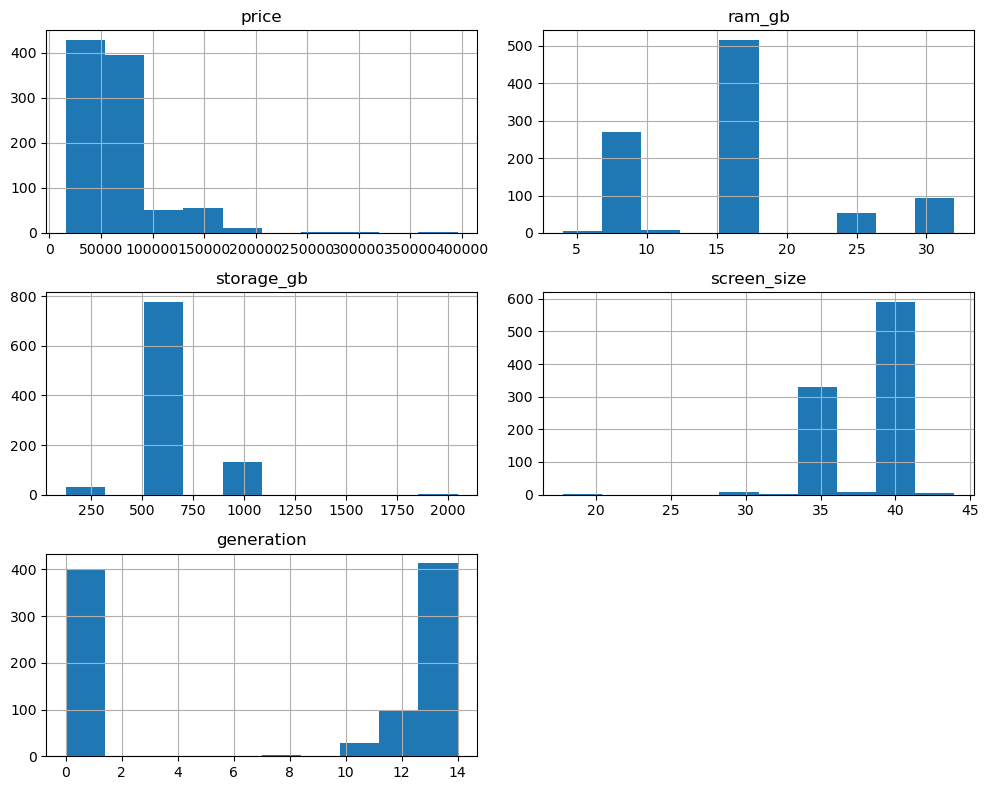

In [38]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

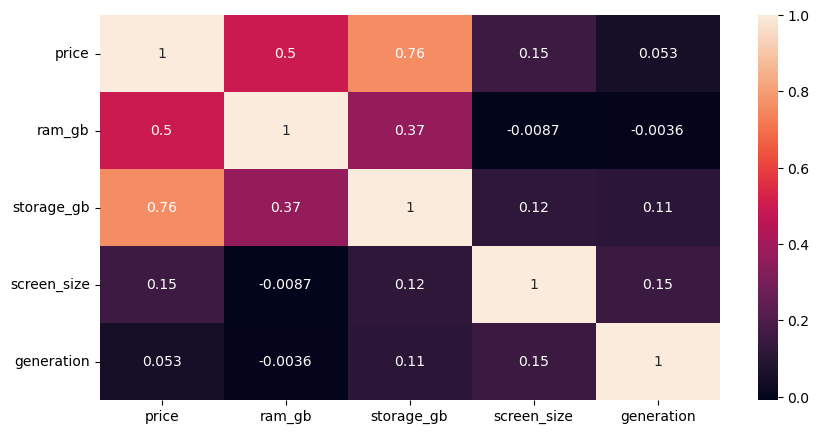

In [82]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: ylabel='price'>

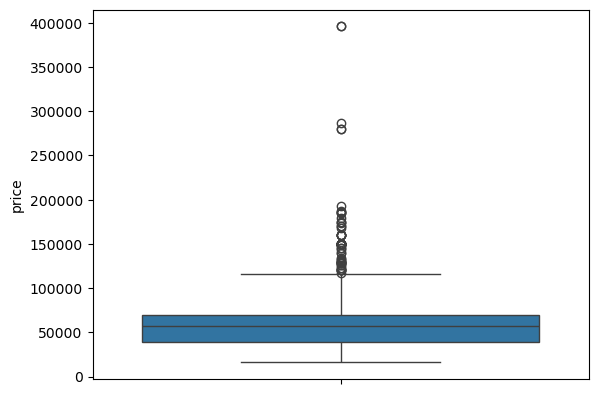

In [86]:
sns.boxplot(data=df, y='price')

# Data Cleaning

In [36]:
df['storage_gb'] = df['storage_gb'].astype('int')

In [38]:
df = df.dropna()
df = df[df['generation'] != 0]
df = df[df['price'] < 300000]

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 543 entries, 0 to 943
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             543 non-null    object 
 1   price             543 non-null    int64  
 2   ram_gb            543 non-null    int64  
 3   storage_gb        543 non-null    int32  
 4   storage_type      543 non-null    object 
 5   screen_size       543 non-null    float64
 6   os                543 non-null    object 
 7   processor_brand   543 non-null    object 
 8   processor_series  543 non-null    object 
 9   generation        543 non-null    int64  
dtypes: float64(1), int32(1), int64(3), object(5)
memory usage: 44.5+ KB


# Model training

In [46]:
cat_cols = df.select_dtypes(include='object').columns
encoders = {}

In [48]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype('str'))
    encoders[col] = le

In [52]:
X = df.drop('price', axis=1)
y = df['price']

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
}

In [88]:
from sklearn.metrics import mean_squared_error, r2_score
results = {}
best_model = None
best_r2 = -999

In [90]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        'mse': round(mse, 2),
        'rmse': round(rmse, 2),
        'r2': round(r2, 4)
    }
    if r2 > best_r2:
        best_r2 = r2
        best_model = name

In [92]:
results

{'Linear Regression': {'mse': 328835451.06, 'rmse': 18133.82, 'r2': 0.7609},
 'Random Forest': {'mse': 270282997.82, 'rmse': 16440.29, 'r2': 0.8035},
 'Gradient Boosting': {'mse': 353956924.74, 'rmse': 18813.74, 'r2': 0.7426}}

In [96]:
print(f"Best model: {best_model} (R2 = {best_r2: .4f})")

Best model: Random Forest (R2 =  0.8035)
